## Chapter 5 : Pretraining On Unlabeled Data


In [69]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
        ]

for p in pkgs:
  print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.0.2
tiktoken version: 0.12.0
torch version: 2.9.0+cpu
tensorflow version: 2.19.0


* In this chapter, we implement the training loop and code for basic model evaluation to pretrain an LLM
* At the end of the chapter, we also load openly available pretrained weights from OpenAI into our model.

## Evaluating generative text models..
* We start this section with a brief-recap of initializing a GPT model using the code from the prev: chapter
* Then we discuss basic evaluation metrics for LLMs
* Lastly we apply these evaluation metrics to a training and validation dataset.


## Using GPT to generate text

* We intialize a GPT model using the code from previous chapter.

In [70]:
import torch
from GPTModel import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,            # Vocabuary size
    "context_length": 256,          # Shortened context length (orig: 1024)
    "emb_dim": 768,                 # Embedding dimension
    "n_heads":12,                   # Number of attention heads
    "n_layers": 12,                   # Number of layers
    "drop_rate": 0.1,                # Droput rate
    "qkv_bias": False               # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()  # Disable dropout during inference


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out

We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays
* Modern LLMs also don't use bias vectors in the nn.Linear layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting "qkv_bias": False

* We reduce the context length (context_length) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens
     * This is so that more readers will be able to follow and execute the code examples on their laptop.
     *

 * Next, we use the generate_text_simple function from the previous chapter to generate text
 * In addition we define 2 convenience functions `text_to_token_ids` and `token_ids_to_text` for converting between token and text representation that we use throughout the chapter
     

In [71]:
import tiktoken
from GPTModel import generate_text_simple


def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # add batch dim
  return encoded_tensor
def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)   # remove batch dimension
  return   tokenizer.decode(flat.tolist())

start_context  = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"])

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))



Output text:
 Every effort moves you rentingetic minion mobilized Macicone warrantyuler respirmediated


* As we can see above, the model does not produce good text because it has not been trained yet
* How do we measure or capture what "good text" is, in a numeric form, to track it during training?
* The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress
* The next chapters on finetuning LLMs will also introduce additional ways to measure model quality

#### Calculating the text generation loss: cross-entropy and preplexity

* Suppose we have an `inputs` tensors containing the token IDs for 2 training examples (rows)
* correspnding to the `inputs` , the `targets` contain the desired token IDs we want the model to generate
* Notice that the `targets` are the `inputs` shifted by ` position .....

In [72]:
inputs = torch.tensor([[16833, 3626,  6100],           # ["every effort moves
                      [40,   1107,   588]])            # 'I really like"]

targets = torch.tensor([[3626, 6100,  345],          # ["effort moves you",
                        [1107,   588,   11311]])     #  "really like chocolate"]

* Feesing the `inputs` to the model , we obtain the logits vector for the 2 input examples that consists of 3 tokens each.
* Each of the tokens is a 50257 -dimensional vector corresponding to the size of the vocabulary

* Applying the softmax function , we can turn the logits tensor into a tensor of the same dim: containing the probability scores.

In [73]:
with torch.no_grad():
  logits = model(inputs)

probas = torch.softmax(logits, dim=-1)    # Probability of each token in vocabulary
print(probas.shape)   # Shape: (batch_size, num_tokens. voacb_size)

torch.Size([2, 3, 50257])


* As discussed in the previous chapter, we can apply the argmax function to convert the probability scores into predicted token IDs
* The softmax function above produced 50,257 dimensional vector for each token, the `argmax` fun: return the position of the highest probability scores in this vector , which is the predicted token ID for the give toen



*     Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:

In [74]:
token_ids = torch.argmax(probas, dim=-1 , keepdim=True)

print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[36195],
         [16031],
         [42826]],

        [[14212],
         [ 7822],
         [38509]]])


* If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens

In [75]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: lif savesNetflix


This is because the model was not trained yet.
# * To train the model, we want to know how far it is away from the correct predictions (targets)



    The token probabilities corresponding to the target indices are as follows:



In [76]:
text_idx = 0
target_probas_1 = probas[text_idx,  [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([4.1353e-05, 1.9397e-05, 1.1213e-05])
Text 2: tensor([1.1875e-05, 4.1576e-05, 5.2655e-06])


* We want to maximize all these values, bringing them close to a probability of 1
* In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself.

In [77]:
# compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([-10.0934, -10.8504, -11.3984, -11.3410, -10.0880, -12.1543])


* Next we compute the average of log probabilities.

In [78]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.9876)


* The goal is to make this average log probability as large as possible by optimizing the model weights
* Due to the log, the largest possible value is 0, and we are currently far away from 0.
* In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0.
* The value negative of (-10.9876),is also called cross-entropy loss in deeplearning



In [79]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.9876)




    Before we apply the `cross_entropy` function, let's check the shape of the logits and targets



In [80]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch-size, num_tokens)
print("Target shape", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Target shape torch.Size([2, 3])


*     For the cross_entropy function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:




In [81]:
logits_flat = logits.flatten(0, 1)
targets_flat  = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


* Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize
* The `cross_entropy` function in PyTorch will automatically take care of applying the softmax and log-probability computation over those token indices in the logits that are to be maximized.

In [82]:
loss  = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.9876)


* A concept related to the cross-entropy loss is the perplexity of an LLM
* The perplexity is simply the exponential of the cross-entropy loss

In [83]:
preplexity = torch.exp(loss)
print(preplexity)

tensor(59135.7969)


* The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens)
* In other words the preplexity provides a measure of how well the probability distribution by the model matches the actual distribution of the words in the dataset
* Similar to the loss, a lower preplexity indicates that the model predictions are closer to the actual distribution.


#### Calculating the training and validation set losses


* We use a relatively small dataset for training the LLM (in fact, only one short story)
The reasons are:
* You can run the code examples in a few minutes on a laptop computer without a suitable GPU
* The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes
* We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size




Below is the same dataset we used in chapter 2.

In [84]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
  response = requests.get(url, timeout=30)
  response.raise_for_status()
  text_data =  response.text
  with open(file_path, "w", encoding="utf-8") as file:
    file.write(text_data)

else:
  with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()




* A quick check that the text loaded ok by printing the first and last 99 characters




In [85]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [86]:
# Last 99 characters
print( text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [87]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


*  With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later)

* Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training.
*

In [88]:
!jupyter nbconvert --to python dataloader.ipynb


[NbConvertApp] Converting notebook dataloader.ipynb to python
[NbConvertApp] Writing 2410 bytes to dataloader.py


In [89]:
from dataloader import create_dataloader_v1

# Training / validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)


val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [90]:
# Sanity check
if total_tokens  * (train_ratio) < GPT_CONFIG_124M["context_length"]:
  print("Not enough tokens in the training loader."
  "Try to lower the `GPT_CONFIG_123['context_length']` or "
  " incrase the `training ratio`"
  )

if total_tokens  * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
  print("Not enoough tokens for te validation loader. "
  "Try to lower the `GPT_CONFIG_124M['context_length]` or "
  "decrease the `training_ratio ")


* We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with
 * Llama 2 7B was trained with a batch size of 1024, for eg:
 * An optional check that the data was loaded correctly


In [91]:
print("Train loader:")
for x, y in train_loader:
  print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
  print(x.shape, y.shape)


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


* Another optional check that the token size are in the expected ballpark:


In [92]:
train_tokens = 0
for input_batch , target_batch in train_loader:
  train_tokens += input_batch.numel()
val_tokens = 0
for input_batch, target_batch in val_loader:
  val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens: ", train_tokens + val_tokens)



Training tokens: 4608
Validation tokens: 512
All tokens:  5120


* Next, we implement a utility function to calculate the cross-entropy loss of a given batch
* In addition we implement a second utility function to compute the loss for a user-specified number of bathces in a data-loader

In [93]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
  return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    # Reduce the number of batches to match the total number of batches in the   data loader
    # if the number_batchecs exceeds the number of batches in the data loader
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch ) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()

    else:
      break
    return total_loss / num_batches


* If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code
* Via the `device` setting, we ensure that the data is loaded into the same device as the LLM model


In [94]:
if torch.cuda.is_available():
  device = torch.device("cuda")

elif torch.backends.mps.is_available():
  # use PyTorch 2.9 or newer for stable mps results
  major, minor = map(int, torch.__version__.split(".")[:2])
  if (major , minor ) >= (2, 9):
    device = torch.device("mps")
  else:
    device = torch.device("cpu")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model.to(device)  # no assignment model = model.to(deivce) necessary for nn.Module classes

torch.manual_seed(123)

with torch.no_grad():  # Disable the gradient tracking for efficiency because we're not training yet.
  train_loss = calc_loss_loader(train_loader,model, device)
  val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss", val_loss)


Using cpu device.
Training loss: 1.2235039605034723
Validation loss 10.982394218444824


## Training an LLM.

* In this section, we finally implement the code for training the LLM


In [95]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
  # Initialize the lists to track the losses and tokens seen
  train_losses , val_losses , track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  # Main training loop
  for epoch in range(num_epochs):
    model.train()   # set the model to training mode

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()  # Reset the loss gradients from prev: batch iteartions
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()  # Calcualte the loss gradients
      optimizer.step()   # Update the model weights using loss gradients
      tokens_seen += input_batch.numel()
      global_step += 1

      # Optional evaluation step
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)

        print(f"Ep {epoch+1} (Step{global_step:06d}): "
        f"train loss {train_loss:.3f}, val loss {val_loss:.3f}")

    # Print a sample text after the each epoch
    generate_and_print_sample(
        model, tokenizer, device, start_context
    )
  return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
  model.train()
  return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)

  with torch.no_grad():
    token_ids = generate_text_simple(
        model=model, idx=encoded,
        max_new_tokens=50, context_size=context_size
    )
  decoded_text =   token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n, " ""))  # Compact print format
  model.train()







## Temperature Scaling
 Previously, we always sampled the token with the highest probability as the next token using torch.argmax

 * To add variety, we can sample the next token using The `torch.multinomial(probs, num_samples=1)`, sampling from a probability distribution

* Here, each index's chance of being picked corresponds to its probability in the input tensor
*

    Here's a little recap of generating the next token, assuming a very small vocabulary for illustration purposes:





In [96]:
vocab = {
    "closer":  0,
    "every":  1,
    "effort":  2,
    "forward":  3,
    "inches":  4,
    "moves":  5,
    "pizza":  6,
    "toward":  7,
    "you":  8,

}

inverse_vocab = {v: k for k , v in vocab.items()}

# Suppose input is "every effort moves you" and the LLM returnes the following logits, for next token
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follow:
print(inverse_vocab[next_token_id])

forward


* We can control the distribution and selection process via a concept called temperature scaling
* "Temperature scaling" is just a fancy word for dividing the logits by a number greater than 0
* Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax
* Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions after applying the softmax


* Note that the resulting  dropout  may look diferent depending on the OS: 🥈

In [97]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)


73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


In [98]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)


# Temperature values
temperatures = [1, 0.1, 5]  # Original , higher cofidence and lower confidence

# Calculate the scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

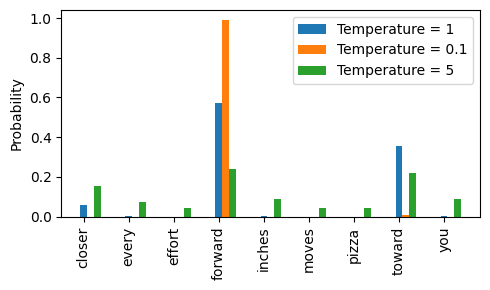

In [99]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

*

    We can see that the rescaling via temperature 0.1 results in a sharper distribution, approaching torch.argmax, such that the most likely word is almost always selected:




In [100]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


* This rescaled probabilities via temperautre 5 are more uniformly distributed


In [101]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you




    Assuming an LLM input "every effort moves you", using the approach above can sometimes result in nonsensical texts, such as "every effort moves you pizza", 3.2% of the time (32 out of 1000 times)



## Top-k sampling ...
*

    To be able to use higher temperatures to increase output diversity and to reduce the probability of nonsensical sentences, we can restrict the sampled tokens to the top-k most likely tokens:




In [102]:
top_k = 3
top_logits , top_pos = torch.topk(next_token_logits, top_k)

print("Top logits", top_logits)
print("Top positions", top_pos)

Top logits tensor([6.7500, 6.2800, 4.5100])
Top positions tensor([3, 7, 0])


In [103]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits,
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [104]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### Modifying the text generation function

* The previous two subsections introduced temperature sampling and top-k sampling
* Let's use these two concepts to modify the `generate_text_simple` function from chapter 4, creating a new `generate` function:

In [105]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

  # For loop is the same as before: Get logits and only focus on last time step
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]

    # New Filter logits with top_k sampling
    if top_k is not  None:
      # Keep only top_k values
      top_logits , _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

    # New :Apply the temperature scaling
    if temperature > 0.0:
      logits = logits / temperature

      # new numerical stability tp to get equivalent results on mps device
      # Subtract rowwise mac before softmax
      logits = logits - logits.max(dim=-1, keepdim=True).values

      # Apply softmax to get the probabilites
      probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

      # Sample from the distribution
      idx_next = torch.multinomial(probs, num_samples=1)   # (batch_size , 1)

    # Otherwise same as before : get idx of the vocab entry with the highest logits
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)
    if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break
    # Same as before append sampled index to the running seeq:
    idx = torch.cat((idx, idx_next), dim=-1)    # (batch_size, num_tokens+1)
  return idx


In [106]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves youEveryiliaralso stabbed Orleans croreean 52atcher uphe Gender schematic Bars embarrassingEss


## Loading and saving model weights in PyTorch

*
    Training LLMs is computationally expensive, so it's crucial to be able to save and load LLM weights




In [107]:
torch.save(model.state_dict(), "model.pth")

* The we can load the model weights into a new `GPTModel` model instance as follows:


In [108]:
model = GPTModel(GPT_CONFIG_124M)


if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  # use PyTorch 2.9 or newer for stable mps results
  major, minor = map(int, torch.__version__.spliy(".")[:2])
  if (major, minor) >= (2, 9):
    device = torch.device("mps")

else:
  device = torch.device("cpu")
print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval()

Device: cpu


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out

It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD
* These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later:

In [110]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)


In [111]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [112]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out

## Loading pretrained weigths from OpenAI

* Previously, we only trained a small GPT-2 model using a very small short-story book for educational purposes
*Fortunately, we don't have to spend tens to hundreds of thousands of dollars to pretrain the model on a large pretraining corpus but can load the pretrained weights provided by OpenAI


In [113]:
!pip install tensorflow tqdm


In [115]:
print("tensorflow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

tensorflow version: 2.19.0
tqdm version: 4.67.1


In [116]:
# Relative import from the gpt_download.py contained in this folder
from gpt_download import download_and_load_gpt2




    We can then download the model weights for the 124 million parameter model as follows:


In [117]:
settings, params= download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 106kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 582kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 152kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:10<00:00, 3.82MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 7.69MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 376kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 435kiB/s]


In [118]:
print("settings", settings)

settings {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [119]:
print("Parameter dictinaory keys:", params.keys())


Parameter dictinaory keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [120]:
print(params["wte"])
print("Token embeddings weight tensor dimension:", params['wte'].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embeddings weight tensor dimension: (50257, 768)


Alternatively, "355M", "774M", and "1558M" are also supported model_size arguments


* Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting `qkv_bias` to True in our implementation, too
* We are also using the `1024` token context length that was used by the original GPT-2 model(s)

In [121]:
# Define the model configuration in a dict: for compcatness

model_congigs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers":12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},

}

#Copy the base configurations and update with specific model settings
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_congigs[model_name])

NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)

gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_f

*     The next task is to assign the `OpenAI` weights to the corresponding weight tensors in our GPTModel instance



In [122]:
def assign(left, right):
  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch . Left: {left.shape} . Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

In [131]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    # Embeddings
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        block = gpt.trf_blocks[b]
        pblock = params["blocks"][b]

        # ---- Attention QKV weights ----
        q_w, k_w, v_w = np.split(
            pblock["attn"]["c_attn"]["w"], 3, axis=-1
        )

        block.att.W_query.weight = assign(block.att.W_query.weight, q_w.T)
        block.att.W_key.weight   = assign(block.att.W_key.weight,   k_w.T)
        block.att.W_value.weight = assign(block.att.W_value.weight, v_w.T)

        # ---- Attention QKV bias ----
        q_b, k_b, v_b = np.split(
            pblock["attn"]["c_attn"]["b"], 3, axis=-1
        )

        block.att.W_query.bias = assign(block.att.W_query.bias, q_b)
        block.att.W_key.bias   = assign(block.att.W_key.bias,   k_b)
        block.att.W_value.bias = assign(block.att.W_value.bias, v_b)

        # ---- Attention output projection ----
        block.att.out_proj.weight = assign(
            block.att.out_proj.weight,
            pblock["attn"]["c_proj"]["w"].T
        )
        block.att.out_proj.bias = assign(
            block.att.out_proj.bias,
            pblock["attn"]["c_proj"]["b"]
        )

        # ---- Feed-forward network ----
        block.ff.layers[0].weight = assign(
            block.ff.layers[0].weight,
            pblock["mlp"]["c_fc"]["w"].T
        )
        block.ff.layers[0].bias = assign(
            block.ff.layers[0].bias,
            pblock["mlp"]["c_fc"]["b"]
        )

        block.ff.layers[2].weight = assign(
            block.ff.layers[2].weight,
            pblock["mlp"]["c_proj"]["w"].T
        )
        block.ff.layers[2].bias = assign(
            block.ff.layers[2].bias,
            pblock["mlp"]["c_proj"]["b"]
        )

        # ---- LayerNorm 1 ----
        block.norm1.scale = assign(block.norm1.scale, pblock["ln_1"]["g"])
        block.norm1.shift = assign(block.norm1.shift, pblock["ln_1"]["b"])

        # ---- LayerNorm 2 ----
        block.norm2.scale = assign(block.norm2.scale, pblock["ln_2"]["g"])
        block.norm2.shift = assign(block.norm2.shift, pblock["ln_2"]["b"])

    # ---- Final LayerNorm ----
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # ---- Output head ----
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_f

    If the model is loaded correctly, we can use it to generate `new text` using our previous generate function:



In [134]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward moving toward goals. [ goals. effort toward effort toward your effort toward goals. effort efforts efforts efforts efforts toward goals toward


*

    We know that we loaded the model weights correctly because the model can generate coherent text; if we made even a small mistake, the model would not be able to do that


*